# 02 探索性数据分析（EDA）

**研究问题**: BA/DS 硕士招生面试考察什么？不同地区与项目类型有何差异？WKU 申请者应如何准备？  
**数据**: `data/pilot_dataset_cleaned.csv`（100 条试点记录，6 个地区 / 80 所院校 / 47 个方向）

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/pilot_dataset_cleaned.csv")
print(f"记录 {len(df)} 条 | 地区 {df['国家/地区'].nunique()} | 院校 {df['院校'].nunique()} | 方向 {df['项目名称'].nunique()}")

记录 100 条 | 地区 6 | 院校 80 | 方向 47


## 1. 地区与面试形式分布

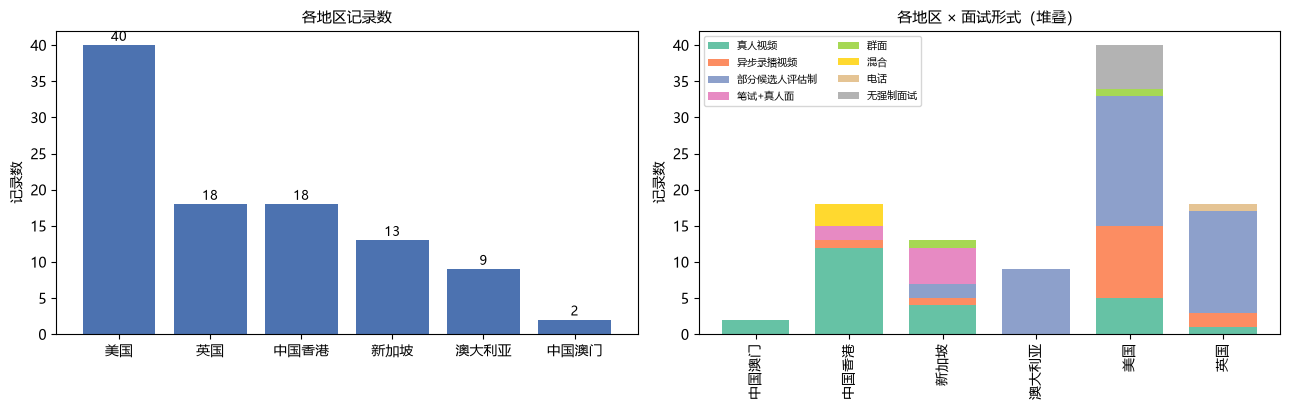

地区 × 面试形式（行占比 %）：
        真人视频  异步录播视频  部分候选人评估制  笔试+真人面   群面    混合   电话  无强制面试
国家/地区                                                        
中国澳门   100.0     0.0       0.0     0.0  0.0   0.0  0.0    0.0
中国香港    66.7     5.6       0.0    11.1  0.0  16.7  0.0    0.0
新加坡     30.8     7.7      15.4    38.5  7.7   0.0  0.0    0.0
澳大利亚     0.0     0.0     100.0     0.0  0.0   0.0  0.0    0.0
美国      12.5    25.0      45.0     0.0  2.5   0.0  0.0   15.0
英国       5.6    11.1      77.8     0.0  0.0   0.0  5.6    0.0


In [2]:
region_order = df["国家/地区"].value_counts().index.tolist()
fmt_order = ["live_video", "async_video", "selective", "written_live", "group", "mixed", "phone", "none"]
fmt_cn = {"live_video": "真人视频", "async_video": "异步录播视频", "selective": "部分候选人评估制",
          "written_live": "笔试+真人面", "group": "群面", "mixed": "混合", "phone": "电话", "none": "无强制面试"}

ct = pd.crosstab(df["国家/地区"], df["面试形式编码"])[fmt_order]
ct.columns = [fmt_cn[c] for c in ct.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
region_cnt = df["国家/地区"].value_counts().reindex(region_order)
ax.bar(region_cnt.index, region_cnt.values, color="#4C72B0")
for i, v in enumerate(region_cnt.values):
    ax.text(i, v + 0.6, str(v), ha="center", fontsize=9)
ax.set_title("各地区记录数", fontsize=11)
ax.set_ylabel("记录数")

ax2 = axes[1]
ct.plot(kind="bar", stacked=True, ax=ax2, colormap="Set2", width=0.72)
ax2.set_title("各地区 × 面试形式（堆叠）", fontsize=11)
ax2.set_xlabel("")
ax2.set_ylabel("记录数")
ax2.legend(fontsize=7.5, ncol=2)
plt.tight_layout()
plt.show()

# 占比表
print("地区 × 面试形式（行占比 %）：")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1).to_string())

## 2. 面试平台

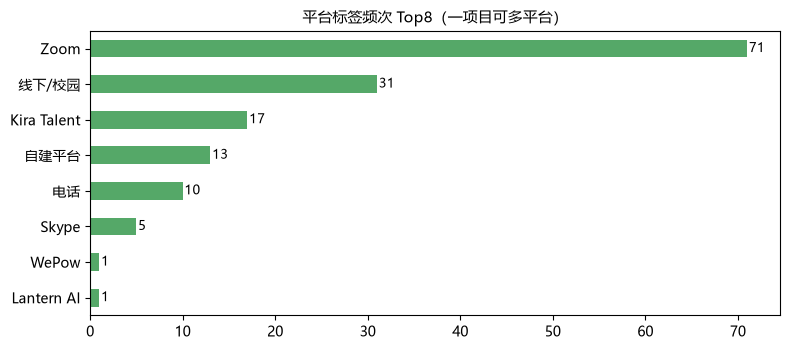

使用 Kira Talent（异步录播主流平台）: 17 个方向 | 使用 Zoom: 71 个方向


In [3]:
from collections import Counter
tag_cnt = Counter()
for tags in df["平台标签"].dropna():
    for t in str(tags).split(","):
        if t:
            tag_cnt[t] += 1
tag_df = pd.Series(tag_cnt).sort_values(ascending=False)
ax = tag_df.head(8).plot(kind="barh", color="#55A868", figsize=(8, 3.6))
ax.set_title("平台标签频次 Top8（一项目可多平台）", fontsize=11)
ax.invert_yaxis()
for i, v in enumerate(tag_df.head(8).values):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()

kira = df["平台标签"].str.contains("Kira").sum()
zoom = df["平台标签"].str.contains("Zoom").sum()
print(f"使用 Kira Talent（异步录播主流平台）: {kira} 个方向 | 使用 Zoom: {zoom} 个方向")

## 3. 问题类型

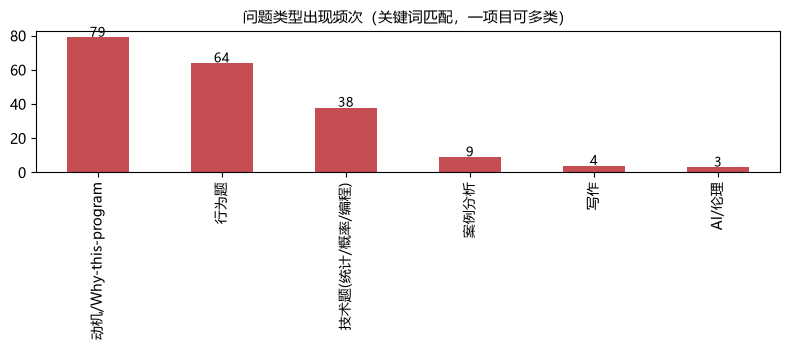

Top2 问题类型: 动机/Why-this-program、行为题


In [4]:
keywords = {
    "行为题": ["行为", "领导力", "团队", "成就", "克服"],
    "动机/Why-this-program": ["为什么", "动机", "Why", "职业规划", "目标"],
    "技术题(统计/概率/编程)": ["技术", "编程", "数学", "统计", "概率", "机器学习", "ML", "算法", "代码"],
    "案例分析": ["案例", "case", "Case"],
    "AI/伦理": ["AI", "伦理", "ethics", "人工智能"],
    "写作": ["写作", "essay", "Essay"],
}
res = {}
for k, kws in keywords.items():
    hits = df["问题类型"].astype(str).apply(lambda s: any(kw in s for kw in kws))
    res[k] = int(hits.sum())
q_df = pd.Series(res).sort_values(ascending=False)
ax = q_df.plot(kind="bar", color="#C44E52", figsize=(8, 3.6))
ax.set_title("问题类型出现频次（关键词匹配，一项目可多类）", fontsize=11)
for i, v in enumerate(q_df.values):
    ax.text(i, v + 0.4, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Top2 问题类型:", "、".join(q_df.index[:2].tolist()))

## 4. 时长与题目量

In [5]:
dur = df.dropna(subset=["时长分钟(解析)"])
g = dur.groupby("国家/地区")["时长分钟(解析)"]       .agg(["count", "median"]).reindex(region_order)
g.columns = ["有记录数", "时长中位数(分钟)"]
print("各地区面试时长中位数（有解析的行）：")
print(g.round(1).to_string())

overall = df["时长分钟(解析)"].median()
print(f"\n全部试点：时长中位数 {overall:.1f} 分钟；报告了题目数的方向中位 {df['题目数量(解析)'].median():.0f} 题")

各地区面试时长中位数（有解析的行）：
       有记录数  时长中位数(分钟)
国家/地区                 
美国       22       17.5
英国       14       17.5
中国香港     13       17.5
新加坡       8       17.5
澳大利亚      5       17.5
中国澳门      2       17.5

全部试点：时长中位数 17.5 分钟；报告了题目数的方向中位 5 题


## 5. 数据来源构成

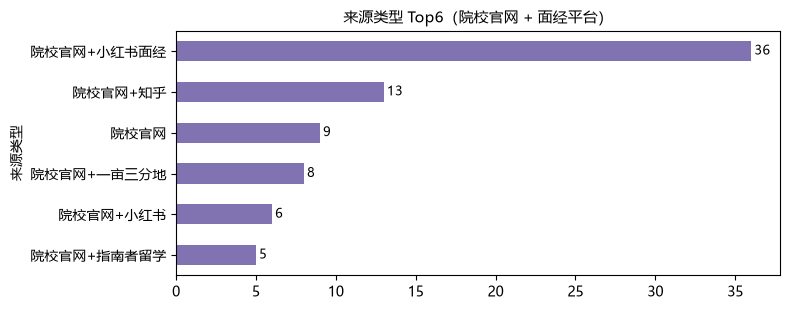

含院校官网交叉验证的记录占比: 100%


In [6]:
src = df["来源类型"].str.replace(" + ", "+", regex=False).value_counts().head(6)
ax = src.plot(kind="barh", color="#8172B2", figsize=(8, 3.2))
ax.set_title("来源类型 Top6（院校官网 + 面经平台）", fontsize=11)
ax.invert_yaxis()
for i, v in enumerate(src.values):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()
official = df["来源类型"].str.contains("院校官网").mean() * 100
print(f"含院校官网交叉验证的记录占比: {official:.0f}%")

## 关键发现（试点版）

1. **面试普遍性**：仅 6/100 个方向「无强制面试」，其余均有不同形式；**43% 为「部分候选人评估制」**，即很多项目对部分申请者不面试——材料（文书/GRE/推荐信）仍是筛选门槛。
2. **形式地区差异**：美国/英国以**异步录播视频（Kira Talent）**为主（如哥大、NYU Stern、帝国理工、UCL）；中国香港/新加坡以**真人视频（Zoom）+ 笔试/机考组合**为主（HKUST 双教授 CV 面、NUS 机面+真人面、SMU 机考+真人面谈）——东亚项目更强调技术笔试。
3. **平台**：Kira Talent（异步）与 Zoom（真人）是两大主流；自建平台多见于美校。
4. **问题类型**：**行为题与动机题（Why-this-program）覆盖最广**；技术题（统计/概率/编程）集中在异步录播与技术向项目；AI 伦理、案例分析开始出现在前沿项目（如 NYU Stern 的 EHICS 讨论、UCSD 数据分析项目）。
5. **时长**：整体中位数约 17.5 分钟；美国部分项目（杜克 MQM 30–45 分钟、沃顿 45 分钟）显著长于英国/香港多数 15–20 分钟。
6. **对 WKU 申请者的启示（试点）**：主攻真人视频+常见行为/动机题库；对东亚项目补充数学/统计/编程笔试准备；录制类（Kira）注意限时作答与写作题。
> 提示：当前为 100 条试点，12 月前将扩展到 ≥300 条并补充 Reddit/访谈数据后做正式推断。